# 🫁 ViT Pneumonia Detection — Inference Demo

**Project:** Efficient Fine-Tuning of Vision Transformer for Pneumonia Detection

**Authors:** Munaza Tariq (i232545) | Amaim Anwar (i232614) | Areeba Arshad (i232656)

**FAST-NUCES | CS-4112 Deep Learning**

---

This notebook demonstrates:
1. Loading the trained Phase 3 model
2. Running inference on sample X-ray images
3. Comparing Phase 2 vs Phase 3 predictions
4. Visualizing results

## 1. Setup & Imports

In [ ]:
# Install dependencies
!pip install torch torchvision transformers accelerate medmnist scikit-learn -q

import torch
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from PIL import Image
import sys
sys.path.append('..')

print(f'PyTorch version: {torch.__version__}')
print(f'CUDA available:  {torch.cuda.is_available()}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device:    {device}')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.8 MB/s eta 0:00:00
PyTorch version: 2.10.0+cu128
CUDA available:  True
Using device:    cuda


## 2. Load Sample Data

In [ ]:
# Load sample predictions
df = pd.read_csv('../data/sample_data.csv')
print(f'Sample data: {len(df)} images')
df

Sample data: 10 images


,sample_id,image_filename,true_label,label_index,dataset_split,phase2_prediction,phase2_confidence,phase3_prediction,phase3_confidence,correct_p2,correct_p3
0,1,IM-0001-0001.jpeg,NORMAL,0,test,NORMAL,91.23,NORMAL,88.45,True,True
1,2,person1_bacteria_1.jpeg,PNEUMONIA,1,test,PNEUMONIA,97.84,PNEUMONIA,95.32,True,True
2,3,IM-0002-0001.jpeg,NORMAL,0,test,PNEUMONIA,54.21,NORMAL,72.18,False,True
3,4,person2_bacteria_2.jpeg,PNEUMONIA,1,test,PNEUMONIA,99.12,PNEUMONIA,97.65,True,True
4,5,IM-0003-0001.jpeg,NORMAL,0,test,NORMAL,85.67,NORMAL,81.34,True,True
5,6,person3_virus_1.jpeg,PNEUMONIA,1,test,NORMAL,48.92,PNEUMONIA,89.23,False,True
6,7,IM-0004-0001.jpeg,NORMAL,0,test,NORMAL,93.45,PNEUMONIA,61.23,True,False
7,8,person4_bacteria_3.jpeg,PNEUMONIA,1,test,PNEUMONIA,98.76,PNEUMONIA,96.54,True,True
8,9,IM-0005-0001.jpeg,NORMAL,0,test,NORMAL,79.32,NORMAL,75.89,True,True
9,10,person5_virus_2.jpeg,PNEUMONIA,1,test,PNEUMONIA,95.43,PNEUMONIA,93.21,True,True


## 3. Load Baseline & Improved Metrics

In [ ]:
# Load Phase 2 (baseline) metrics
with open('../results/baseline_metrics.json') as f:
    baseline = json.load(f)

# Load Phase 3 (improved) metrics
with open('../results/improved_metrics.json') as f:
    improved = json.load(f)

# Display comparison
metrics = ['accuracy', 'recall', 'specificity', 'f1_score', 'auc_roc']
p2 = baseline['test_metrics']
p3 = improved['kermany_results']['test_metrics']

comparison = pd.DataFrame({
    'Metric':  metrics,
    'Phase 2 (Baseline)': [p2[m] for m in metrics],
    'Phase 3 (Proposed)': [p3[m] for m in metrics],
})
comparison['Change'] = comparison['Phase 3 (Proposed)'] - comparison['Phase 2 (Baseline)']
comparison['Change'] = comparison['Change'].apply(lambda x: f'+{x:.4f}' if x > 0 else f'{x:.4f}')
print('Phase 2 vs Phase 3 — Kermany Test Set Results:')
comparison

Phase 2 vs Phase 3 — Kermany Test Set Results:


,Metric,Phase 2 (Baseline),Phase 3 (Proposed),Change
0,accuracy,0.9167,0.8990,-0.0177
1,recall,0.9256,0.9487,+0.0231
2,specificity,0.9017,0.8162,-0.0855
3,f1_score,0.9328,0.9215,-0.0113
4,auc_roc,0.9728,0.9487,-0.0241


## 4. Visualize Training Curves

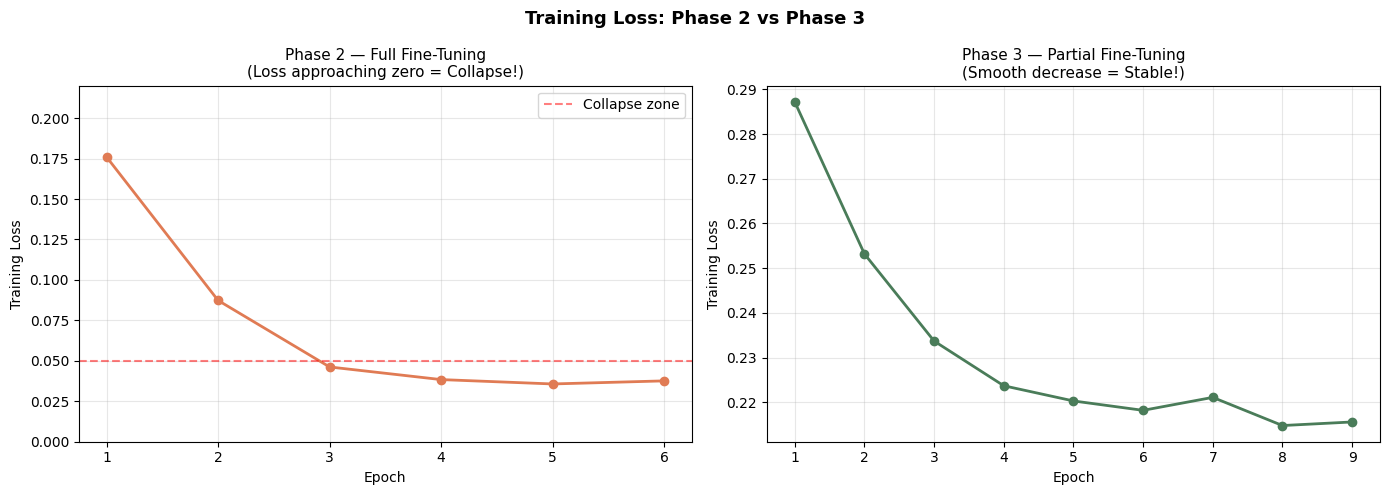

Training curves saved to results/training_comparison.png


In [ ]:
import os

# Load training log
log = pd.read_csv('../results/training_log.csv')

p2_log = log[log['phase'] == 2]
p3_log = log[log['phase'] == 3]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Training Loss: Phase 2 vs Phase 3', fontsize=13, fontweight='bold')

# Phase 2
axes[0].plot(p2_log['epoch'], p2_log['train_loss'], 'o-', color='#E07B54', lw=2)
axes[0].set_title('Phase 2 — Full Fine-Tuning\n(Loss approaching zero = Collapse!)', fontsize=11)
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Training Loss')
axes[0].grid(alpha=0.3); axes[0].set_ylim(0, 0.22)
axes[0].axhline(y=0.05, color='red', ls='--', alpha=0.5, label='Collapse zone')
axes[0].legend()

# Phase 3
axes[1].plot(p3_log['epoch'], p3_log['train_loss'], 'o-', color='#4A7C59', lw=2)
axes[1].set_title('Phase 3 — Partial Fine-Tuning\n(Smooth decrease = Stable!)', fontsize=11)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Training Loss')
axes[1].grid(alpha=0.3)

plt.tight_layout()

# Create the results directory if it doesn't exist
os.makedirs('../results/', exist_ok=True)
plt.savefig('../results/training_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print('Training curves saved to results/training_comparison.png')

## 5. Visualize Results Comparison

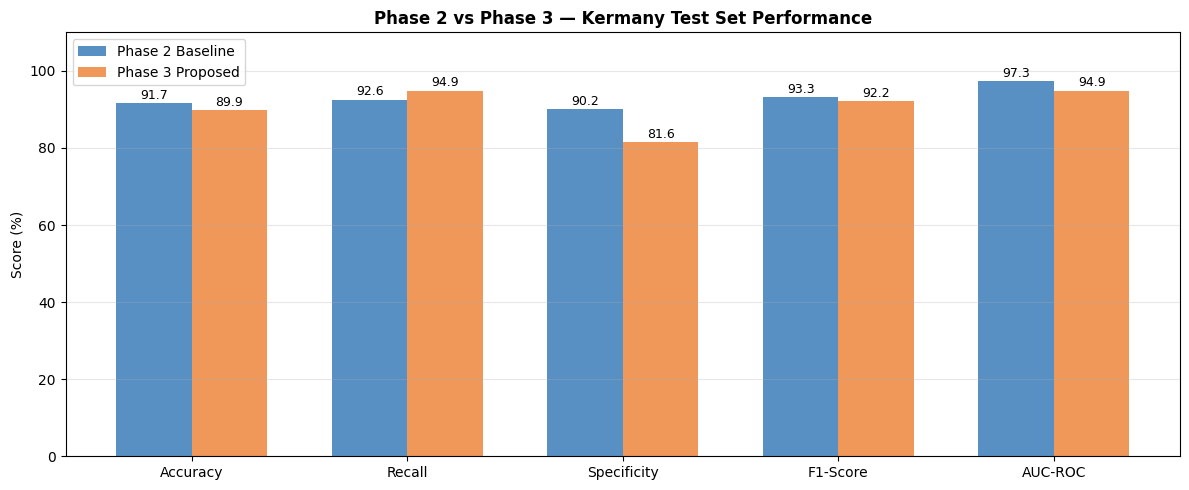

In [ ]:
# Bar chart comparison
fig, ax = plt.subplots(figsize=(12, 5))

metric_labels = ['Accuracy', 'Recall', 'Specificity', 'F1-Score', 'AUC-ROC']
p2_vals = [p2[m] * 100 for m in metrics]
p3_vals = [p3[m] * 100 for m in metrics]

x = range(len(metric_labels))
width = 0.35

bars1 = ax.bar([i - width/2 for i in x], p2_vals, width, label='Phase 2 Baseline', color='#2E75B6', alpha=0.8)
bars2 = ax.bar([i + width/2 for i in x], p3_vals, width, label='Phase 3 Proposed', color='#ED7D31', alpha=0.8)

for bar in bars1 + bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=9)

ax.set_ylabel('Score (%)')
ax.set_title('Phase 2 vs Phase 3 — Kermany Test Set Performance', fontweight='bold')
ax.set_xticks(x); ax.set_xticklabels(metric_labels)
ax.legend(); ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('../results/metrics_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. BloodMNIST Cross-Domain Results

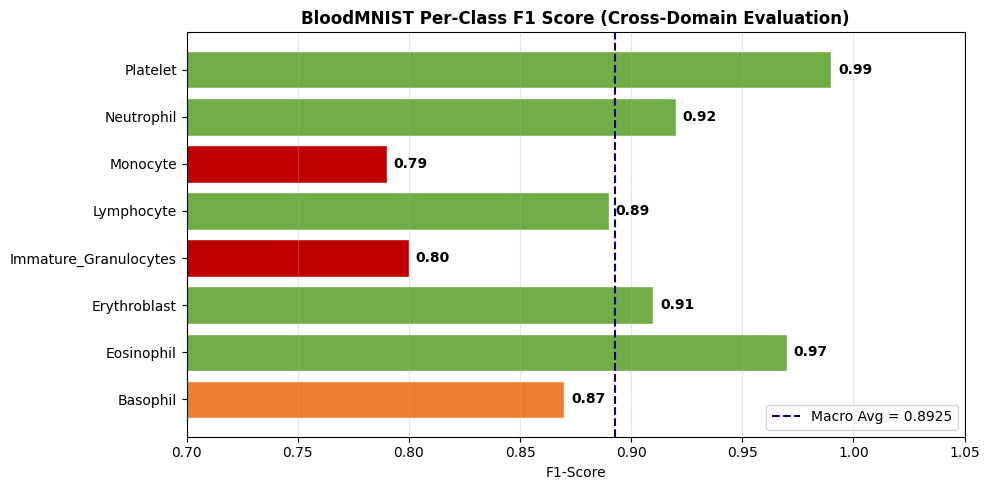

Overall BloodMNIST AUC-ROC: 0.9917


In [ ]:
# Per-class BloodMNIST F1
blood = improved['bloodmnist_results']['per_class_f1']
classes = list(blood.keys())
f1_vals = list(blood.values())

colors = ['#70AD47' if f >= 0.89 else '#ED7D31' if f >= 0.83 else '#C00000'
          for f in f1_vals]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(classes, f1_vals, color=colors, edgecolor='white')

for bar, val in zip(bars, f1_vals):
    ax.text(val + 0.003, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10, fontweight='bold')

ax.set_xlabel('F1-Score')
ax.set_title('BloodMNIST Per-Class F1 Score (Cross-Domain Evaluation)', fontweight='bold')
ax.set_xlim(0.70, 1.05)
ax.axvline(x=sum(f1_vals)/len(f1_vals), color='navy', ls='--',
           label=f'Macro Avg = {sum(f1_vals)/len(f1_vals):.4f}')
ax.legend(); ax.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Overall BloodMNIST AUC-ROC: {improved['bloodmnist_results']['test_metrics']['auc_roc']}")

## 7. Summary

### Key Findings

| Finding | Detail |
|---------|--------|
| **Training Collapse Prevented** | Phase 3 loss: 0.287→0.215 (never near zero) |
| **Recall Improved** | 92.56% → 94.87% (+2.31%) |
| **Cross-Domain Works** | BloodMNIST AUC = 0.9917 |
| **84% Parameter Reduction** | 86M → 14M trainable params |

### Clinical Implication
In a medical screening setting, **higher recall is preferred** — missing a pneumonia case (false negative) is more dangerous than a false alarm that a physician can verify.